# RQ1 — Oracle Validation Analysis

*Real-only notebook: loads the latest persisted experiment report JSON and analyzes it. No simulations.*


## Load latest RQ1 report

In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)

REPORT_DIR = Path('../results/rq1')
report_files = sorted(REPORT_DIR.glob('rq1_report_*.json'), key=lambda p: p.stat().st_mtime, reverse=True)
if not report_files:
    raise FileNotFoundError(
        f'No RQ1 report found in {REPORT_DIR.resolve()}. Run experiments/rq1_oracle_validation.py to generate rq1_report_*.json'
    )
REPORT_PATH = report_files[0]
print('Using report:', REPORT_PATH)

report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
report.keys()


Using report: ../results/rq1/rq1_report_httpbin_testing_api_c100_20251213_041306.json


dict_keys(['experiment_id', 'config', 'started_at', 'completed_at', 'total_endpoints', 'endpoint_results', 'aggregate_metrics', 'llm_rankings', 'successful_generations', 'failed_generations'])

## Build endpoint-level metrics table

In [3]:
rows = []
for er in report.get('endpoint_results', []):
    endpoint_id = er.get('endpoint_id')
    endpoint_name = er.get('endpoint_name')
    exec_times = er.get('execution_times', {}) or {}
    errors = er.get('errors', {}) or {}
    metrics = er.get('metrics', {}) or {}
    for model, m in metrics.items():
        rows.append({
            'endpoint_id': endpoint_id,
            'endpoint_name': endpoint_name,
            'llm_model': model,
            'precision': m.get('precision'),
            'recall': m.get('recall'),
            'f1_score': m.get('f1_score'),
            'completeness_score': m.get('completeness_score'),
            'true_positives': m.get('true_positives'),
            'false_positives': m.get('false_positives'),
            'false_negatives': m.get('false_negatives'),
            'execution_time_s': exec_times.get(model),
            'error': errors.get(model),
        })

endpoint_metrics_df = pd.DataFrame(rows)
endpoint_metrics_df.head(10)


,endpoint_id,endpoint_name,llm_model,precision,recall,f1_score,completeness_score,true_positives,false_positives,false_negatives,execution_time_s,error
0,f080b308-6bbf-43a7-854a-9c670ec1132a,GET request,llama32,1.000000,0.333333,0.500000,0.333333,1,0,2,36.410496,None
1,6c560818-a3f8-40f3-8854-cb999e6dae9e,POST request,llama32,1.000000,0.166667,0.285714,0.166667,1,0,5,36.410496,None
2,5da2add9-204b-460f-b908-9ae501e67f8f,Status 200,llama32,1.000000,0.333333,0.500000,0.333333,1,0,2,36.410496,None
3,f7ff8cb5-a0a9-483a-bb3e-8b1d0bc7d143,Status 404,llama32,0.285714,0.666667,0.400000,0.666667,2,5,1,36.410496,None
4,45085b49-122c-4bb1-900b-881b3d17aba0,Status 500,llama32,1.000000,0.333333,0.500000,0.333333,1,0,2,36.410496,None
5,6d3f5610-56f0-4eb0-b2d8-12008263afdc,Get headers,llama32,1.000000,0.333333,0.500000,0.333333,1,0,2,36.410496,None
6,5ce0c2f9-2178-4290-8fe4-9d0e4c7aa3cb,Delayed response,llama32,0.285714,0.666667,0.400000,0.666667,2,5,1,36.410496,None
7,c4eee30c-ac2d-4dcb-88bd-d371164ba647,Basic authentication,llama32,0.428571,0.750000,0.545455,0.750000,3,4,1,36.410496,None


## Aggregate metrics (from report + recompute sanity check)

In [4]:
aggregate_metrics = report.get('aggregate_metrics', {}) or {}
aggregate_df = (
    pd.DataFrame.from_dict(aggregate_metrics, orient='index')
      .reset_index(names='llm_model')
      .sort_values('f1_mean', ascending=False)
)

display(aggregate_df)

if not endpoint_metrics_df.empty:
    recomputed = endpoint_metrics_df.groupby('llm_model').agg(
        precision_mean=('precision', 'mean'),
        recall_mean=('recall', 'mean'),
        f1_mean=('f1_score', 'mean'),
        completeness_mean=('completeness_score', 'mean'),
        n=('endpoint_id', 'count'),
    ).reset_index()
    display(recomputed.sort_values('f1_mean', ascending=False))


,llm_model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,completeness_mean,completeness_std
0,llama32,0.75,0.347838,0.447917,0.213333,0.453896,0.08534,0.447917,0.213333


,llm_model,precision_mean,recall_mean,f1_mean,completeness_mean,n
0,llama32,0.75,0.447917,0.453896,0.447917,8


## Visualizations

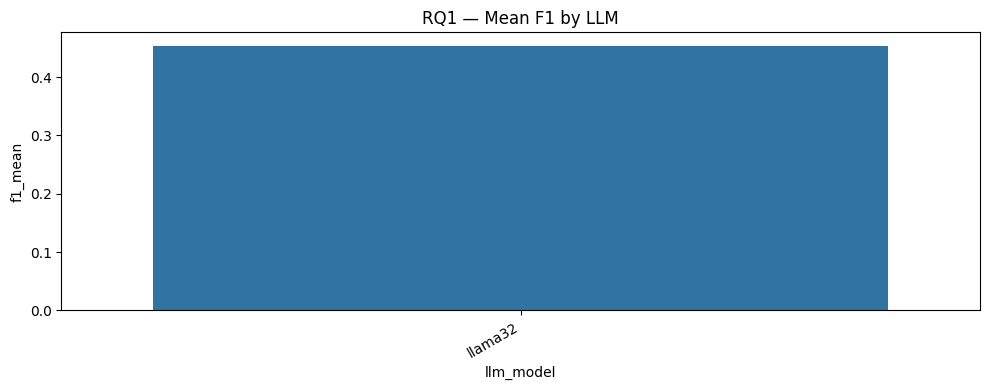

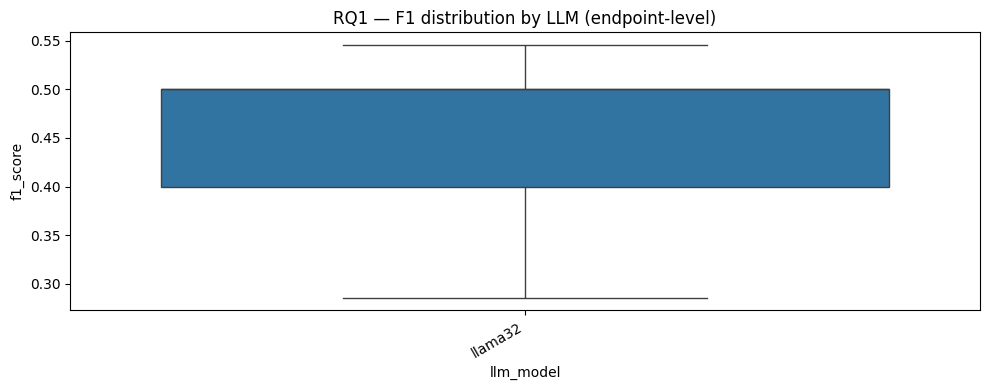

In [5]:
if aggregate_df.empty:
    raise ValueError('No aggregate metrics present in report.')

plt.figure(figsize=(10, 4))
sns.barplot(data=aggregate_df, x='llm_model', y='f1_mean')
plt.title('RQ1 — Mean F1 by LLM')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

if not endpoint_metrics_df.empty:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=endpoint_metrics_df, x='llm_model', y='f1_score')
    plt.title('RQ1 — F1 distribution by LLM (endpoint-level)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


## Export

In [6]:
OUT_DIR = Path('./outputs/rq1')
OUT_DIR.mkdir(parents=True, exist_ok=True)

endpoint_metrics_df.to_csv(OUT_DIR / 'rq1_endpoint_metrics.csv', index=False)
aggregate_df.to_csv(OUT_DIR / 'rq1_aggregate_metrics.csv', index=False)

summary = {
    'report_path': str(REPORT_PATH),
    'experiment_id': report.get('experiment_id'),
    'total_endpoints': report.get('total_endpoints'),
    'llm_rankings': report.get('llm_rankings'),
}
(OUT_DIR / 'rq1_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('Wrote:', OUT_DIR)


Wrote: outputs/rq1
